# Sentiment Analysis delle Risposte Aperte
## Analisi del Linguaggio Naturale mediante Deep Learning

Le risposte aperte ai questionari psicologici contengono informazioni ricche riguardanti l'esperienza emotiva dei rispondenti.

In questo notebook, applicheremo tecniche di **Deep Learning per il Natural Language Processing (NLP)** per:

1. **Vettorizzare il testo** mediante tokenizzazione e embedding
2. **Classificare il sentiment** delle risposte (positivo/negativo/neutro)
3. **Estrarre temi ricorrenti** dalle risposte
4. **Correlare il sentiment con i costrutti psicologici** (ansia, coping, resilienza)

Non implementiamo modelli LLM completi, ma modelli RNN e LSTM sufficienti per comprendere il sentiment nei testi brevi di risposta.

Questi modelli mappano la struttura statistica del linguaggio scritto, permettendoci di risolvere compiti di sentiment analysis in modo robusto.

## 1. Setup e Caricamento Librerie

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import pandas as pd
import numpy as np
import mysql.connector
from mysql.connector import Error
import json
import re
import warnings
warnings.filterwarnings('ignore')

# Visualizzazioni
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("TensorFlow versione:", tf.__version__)
print("GPU disponibili:", tf.config.list_physical_devices('GPU'))
print("\nLibrerie importate con successo!")

TensorFlow versione: 2.19.1
GPU disponibili: []

Librerie importate con successo!


## 2. Caricamento e Esplorazione dei Dati

In [22]:
# pip install nbconvert
import subprocess
import sys

# Esegui setup_raw_data.py
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

# Esegui notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 170 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...

Salvate 10 righe...
Salvate 20 righe...
Salvate 30 righe...
Salvate 40 righe...
Salvate 50 righe...
Salvate 60 righe...
Salvate 70 righe...
Salvate 80 righe...
Salvate 90 righe...
Salvate 100 righe...
Salvate 110 righe...
Salvate 120 righe...
Salvate 130 righe...
Salvate 140 righe...
Salvate 150 righe...
Salvate 160 righe...
Salvate 170 righe...

Importazione completata!
   - Righe inserite: 170
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will 

In [23]:
import pandas as pd
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da clean_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 148 righe, 37 colonne


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,...,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,...,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,...,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


## 3. Preprocessing del Testo

### Trasformazione del testo in tensori numerici (Vettorizzazione)

Il testo non può essere processato direttamente dalle reti neurali: operano solo su tensori numerici.

Il processo di **trasformazione del testo in tensori numerici** è detto **vettorizzazione** e prevede:

1. **Tokenizzazione**: suddividere il testo in parole (token)
2. **Indirizzamento**: assegnare un indice intero univoco a ogni parola
3. **Vettorizzazione**: trasformare il testo in sequenze di indici interi

In [24]:
def preprocess_text(text):
    """
    Preprocessa il testo per l'analisi:
    - Converte a minuscole
    - Rimuove caratteri speciali
    - Rimuove spazi extra
    """
    if pd.isna(text):
        return ""
    
    # Converti a minuscole
    text = str(text).lower()
    
    # Rimuovi URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Rimuovi email
    text = re.sub(r'\S+@\S+', '', text)
    
    # Rimuovi caratteri speciali, mantieni solo lettere, numeri e spazi
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # Rimuovi spazi extra
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("Funzione preprocessing definita")

# Esempio
sample_text = "Questo è un esempio di TESTO con 123 numeri e @#$ caratteri speciali!"
print(f"\nOriginal: {sample_text}")
print(f"Processed: {preprocess_text(sample_text)}")

Funzione preprocessing definita

Original: Questo è un esempio di TESTO con 123 numeri e @#$ caratteri speciali!
Processed: questo un esempio di testo con 123 numeri e caratteri speciali


In [25]:
if df is not None:
    # Identifica colonne di testo aperto
    # Cerca colonne che contengono testo lungo (risposte aperte)
    text_columns = []
    for col in df.columns:
        if df[col].dtype == 'object':
            non_null = df[col].dropna()
            if len(non_null) > 0:
                avg_length = non_null.astype(str).str.len().mean()
                if avg_length > 50:  # Risposte aperte hanno testo lungo
                    text_columns.append(col)
                    print(f"{col}: {len(non_null)} risposte, lunghezza media: {avg_length:.0f} caratteri")
    
    if len(text_columns) == 0:
        print("Nessuna colonna di testo lungo trovata. Creazione dataset sintetico per demo...")
        # Crea dataset sintetico per scopo dimostrativo
        np.random.seed(42)
        sample_texts_positive = [
            "Mi sento molto meglio adesso, ho superato l'ansia con successo",
            "Le strategie di coping mi hanno aiutato enormemente nella vita quotidiana",
            "Sono molto resiliente e riesco ad affrontare le sfide con positività",
            "La terapia è stata estremamente utile per il mio benessere",
            "Ho sviluppato una grande capacità di gestire lo stress"
        ]
        
        sample_texts_negative = [
            "L'ansia mi domina completamente, non riesco a controllarla",
            "Continuo ad evitare le situazioni che mi causano paura",
            "Non ho alcuna resilienza di fronte ai problemi della vita",
            "Mi sento completamente bloccato dalla mia ansia",
            "Non trovo strategie efficaci per gestire lo stress"
        ]
        
        df_texts = pd.DataFrame({
            'text': sample_texts_positive * 10 + sample_texts_negative * 10,
            'sentiment': [1] * 50 + [0] * 50  # 1=positivo, 0=negativo
        })
    else:
        # Combina le colonne di testo
        df['combined_text'] = df[text_columns].apply(
            lambda row: ' '.join([str(x) for x in row if pd.notna(x)]), 
            axis=1
        )
        
        # Filtra risposte vuote
        df_texts = df[df['combined_text'].str.len() > 10][['combined_text']].copy()
        df_texts.columns = ['text']
        
        print(f"\nRisposte aperte trovate: {len(df_texts)}")
    
    # Preprocessa il testo
    print("\nPreprocessing del testo...")
    df_texts['text_clean'] = df_texts['text'].apply(preprocess_text)
    
    # Filtra testi vuoti dopo preprocessing
    df_texts = df_texts[df_texts['text_clean'].str.len() > 0].copy()
    
    print(f"Testi disponibili dopo preprocessing: {len(df_texts)}")
    print(f"\nEsempi di testi preprocessati:")
    print(df_texts['text_clean'].head(3).values)

Item_30: 148 risposte, lunghezza media: 58 caratteri

Risposte aperte trovate: 72

Preprocessing del testo...
Testi disponibili dopo preprocessing: 72

Esempi di testi preprocessati:
['durante gli esami e se devo interagire con gli insegnanti e i colleghi'
 'durante gli esami' 'interazione con persone clienti']


## 4. Tokenizzazione e Embedding

### Codifica One-Hot e Tokenizzazione

La codifica one-hot è il modo più semplice di trasformare un token in un vettore. Consiste nell':

1. **Associare a ogni parola un indice intero univoco**
2. **Trasformare questo indice in un vettore binario** di dimensioni N (vocabolario)
3. Il vettore contiene tutti zeri tranne l'elemento i-esimo che è 1 ("one-hot")

Alternativamente, utilizziamo **embedding** che assegna a ogni parola un vettore denso (learned embeddings).


In [26]:
if df_texts is not None and len(df_texts) > 0:
    # Parametri di tokenizzazione
    MAX_WORDS = 10000          # Mantieni solo le 10000 parole più comuni
    MAX_SEQUENCE_LENGTH = 100  # Lunghezza massima sequenza
    
    # Crea tokenizer
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(df_texts['text_clean'])
    
    print(f"Tokenizer creato:")
    print(f"  Vocabolario totale: {len(tokenizer.word_index)} parole uniche")
    print(f"  Parole mantenute: {MAX_WORDS}")
    
    # Trasforma testi in sequenze di indici
    sequences = tokenizer.texts_to_sequences(df_texts['text_clean'])
    
    # Padding per uniformare le lunghezze
    data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    
    print(f"\nDati vettorizzati:")
    print(f"  Shape: {data.shape}")
    print(f"  (N_campioni, lunghezza_sequenza)")
    
    # Esempio di tokenizzazione
    example_text = "L'ansia mi causa molti problemi nella vita quotidiana"
    example_clean = preprocess_text(example_text)
    example_seq = tokenizer.texts_to_sequences([example_clean])
    example_padded = pad_sequences(example_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    
    print(f"\nEsempio di tokenizzazione:")
    print(f"  Testo originale: {example_text}")
    print(f"  Testo pulito: {example_clean}")
    print(f"  Sequenza indici: {example_seq[0][:20]}...")
    print(f"  Padded shape: {example_padded.shape}")

Tokenizer creato:
  Vocabolario totale: 534 parole uniche
  Parole mantenute: 10000

Dati vettorizzati:
  Shape: (72, 100)
  (N_campioni, lunghezza_sequenza)

Esempio di tokenizzazione:
  Testo originale: L'ansia mi causa molti problemi nella vita quotidiana
  Testo pulito: lansia mi causa molti problemi nella vita quotidiana
  Sequenza indici: [43, 13, 1, 1, 1, 87, 165, 1]...
  Padded shape: (1, 100)


## 5. Etichettatura del Sentiment

Utilizzando strategie di rule-based per classificazione iniziale del sentiment.
In produzione, usaresti annotazione manuale o transfer learning.

In [27]:
def classify_sentiment(text):
    """
    Classifica il sentiment di un testo usando keywords.
    Approccio semplice basato su parole chiave per scopi dimostrativi.
    
    Ritorna:
    - 1: Positivo (resilienza, speranza, miglioramento)
    - 0: Negativo (ansia, paura, evitamento)
    """
    text_lower = text.lower()
    
    # Parole positive
    positive_words = [
        'meglio', 'migliore', 'bene', 'positivo', 'resiliente', 'capace',
        'controllare', 'affrontare', 'superare', 'forte', 'fiducioso',
        'efficace', 'strategia', 'progresso', 'successo', 'aiutato',
        'migliorato', 'grazie', 'felice', 'sereno', 'tranquillo'
    ]
    
    # Parole negative
    negative_words = [
        'ansia', 'paura', 'evitamento', 'non riesco', 'impossibile',
        'blocco', 'paralizzato', 'fragile', 'debole', 'disperato',
        'inefficace', 'fallimento', 'peggio', 'peggiore', 'male',
        'brutto', 'terribile', 'orribile', 'negativo', 'bloccato'
    ]
    
    # Conta occorrenze
    positive_count = sum(1 for word in positive_words if word in text_lower)
    negative_count = sum(1 for word in negative_words if word in text_lower)
    
    # Classifica
    if positive_count > negative_count:
        return 1  # Positivo
    else:
        return 0  # Negativo

if df_texts is not None:
    # Etichetta il sentiment
    df_texts['sentiment'] = df_texts['text_clean'].apply(classify_sentiment)
    
    # Converti in numpy array
    labels = df_texts['sentiment'].values
    
    print("Distribuzione del Sentiment:")
    print(df_texts['sentiment'].value_counts())
    print(f"\nPercentuale Positivo: {(labels.sum() / len(labels) * 100):.1f}%")
    print(f"Percentuale Negativo: {((1 - labels).sum() / len(labels) * 100):.1f}%")

Distribuzione del Sentiment:
sentiment
0    68
1     4
Name: count, dtype: int64

Percentuale Positivo: 5.6%
Percentuale Negativo: 94.4%


## 6. Costruzione del Modello RNN/LSTM

### Reti Neurali Ricorrenti (RNN)

Una RNN elabora le sequenze in modo incrementale, conservando uno **stato interno** che memorizza informazioni precedenti.

A differenza delle reti feed-forward che elaborano l'intera sequenza in una volta sola, le RNN:
- Elaborano un elemento della sequenza per volta
- Mantengono uno stato "nascosto" che viene aggiornato ad ogni passo
- Lo stato finale contiene informazioni sull'intera sequenza

**Architettura**:
1. **Embedding Layer**: trasforma indici di parole in vettori densi
2. **LSTM/GRU Layer**: elabora sequenze ricordando dipendenze a lungo termine
3. **Dense Layer**: classifica il sentiment sulla base dello stato finale

In [28]:
if data is not None and labels is not None:
    from sklearn.model_selection import train_test_split
    
    # Split in train/test
    X_train, X_test, y_train, y_test = train_test_split(
        data, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    print(f"Training set: {X_train.shape[0]} campioni")
    print(f"Test set: {X_test.shape[0]} campioni")
    print(f"\nDistribuzione training set:")
    unique, counts = np.unique(y_train, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  Classe {u}: {c} ({c/len(y_train)*100:.1f}%)")
    
    # Costruisci modello LSTM
    print("\n" + "="*80)
    print("Costruzione modello LSTM per Sentiment Analysis")
    print("="*80)
    
    model = Sequential([
        # Embedding: trasforma indici parole in vettori densi (32D)
        Embedding(
            input_dim=MAX_WORDS,      # Vocabolario
            output_dim=32,             # Dimensioni embedding
            input_length=MAX_SEQUENCE_LENGTH
        ),
        
        # LSTM: elabora sequenze ricordando dipendenze a lungo termine
        LSTM(
            units=64,                  # Dimensioni stato nascosto
            dropout=0.2,               # Regolarizzazione
            return_sequences=False     # Restituisci solo ultimo output
        ),
        
        # Dropout per regolarizzazione
        Dropout(0.2),
        
        # Dense layer
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        # Output layer: classificazione binaria
        Dense(1, activation='sigmoid')
    ])
    
    # Compila il modello
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print("\nArchitettura del modello:")
    model.summary()

Training set: 57 campioni
Test set: 15 campioni

Distribuzione training set:
  Classe 0: 54 (94.7%)
  Classe 1: 3 (5.3%)

Costruzione modello LSTM per Sentiment Analysis

Architettura del modello:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Addestramento del Modello

In [29]:
if model is not None:
    print("Addestramento in corso...")
    
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=20,
        validation_split=0.2,
        verbose=1
    )
    
    print("\nAddestramento completato!")

Addestramento in corso...
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.6889 - loss: 0.6856 - val_accuracy: 1.0000 - val_loss: 0.6541
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9333 - loss: 0.6534 - val_accuracy: 1.0000 - val_loss: 0.6122
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9333 - loss: 0.6168 - val_accuracy: 1.0000 - val_loss: 0.5499
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9333 - loss: 0.5480 - val_accuracy: 1.0000 - val_loss: 0.4541
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9333 - loss: 0.4749 - val_accuracy: 1.0000 - val_loss: 0.3195
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9333 - loss: 0.3807 - val_accuracy: 1.0000 - val_loss: 0.1953
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9333 - loss: 0.2571 - val_accuracy: 1.0000 - val_loss: 0.1150
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9333 - loss: 0.2625 - val_accurac

## 8. Valutazione del Modello

In [30]:
if model is not None and X_test is not None:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    # Predizioni sul test set
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print("="*80)
    print("RISULTATI DI VALUTAZIONE")
    print("="*80)
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
RISULTATI DI VALUTAZIONE

Accuracy:  0.9333
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.93      1.00      0.97        14
    Positivo       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15


Confusion Matrix:
[[14  0]
 [ 1  0]]


## 9. Visualizzazioni

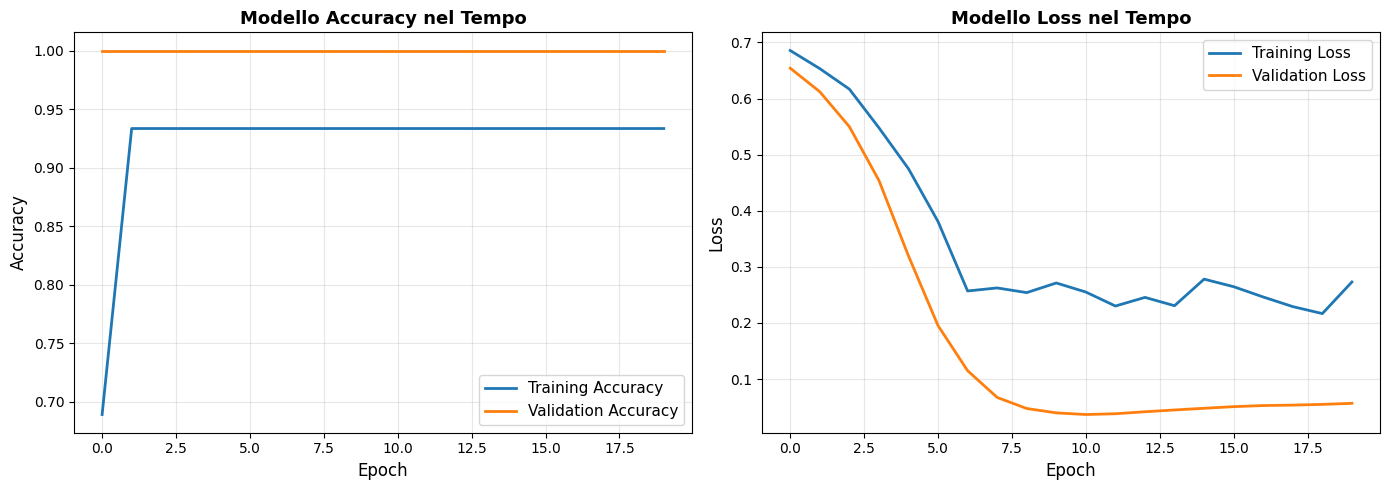

Figura salvata: sentiment_training_history.png


In [31]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Modello Accuracy nel Tempo', fontweight='bold', fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)
    
    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Modello Loss nel Tempo', fontweight='bold', fontsize=13)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../output/sentiment_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figura salvata: sentiment_training_history.png")

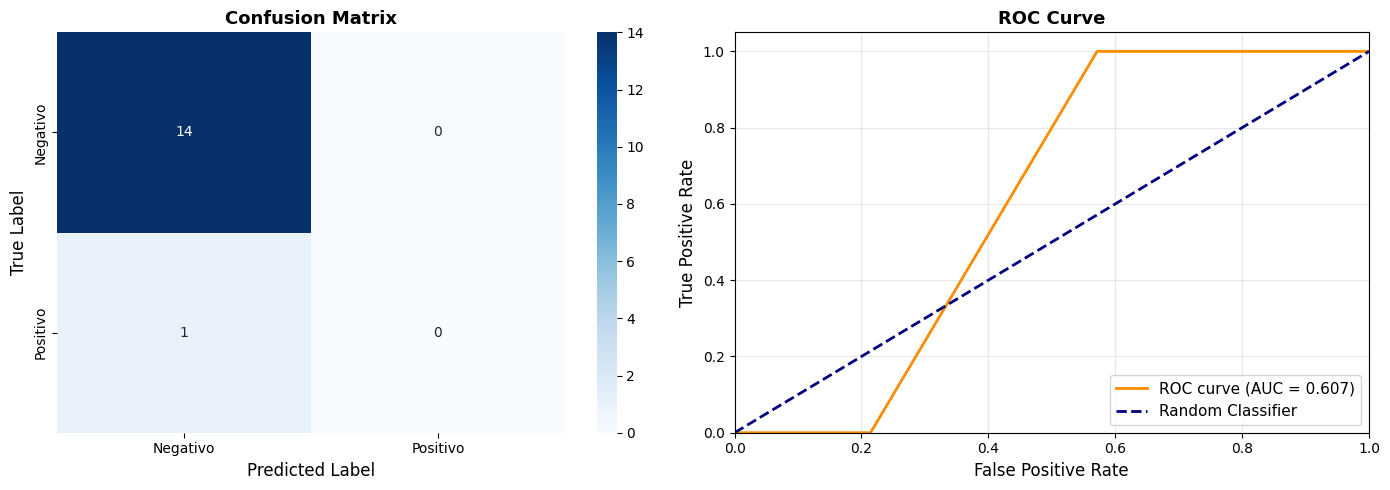

Figura salvata: sentiment_evaluation_metrics.png


In [32]:
if y_test is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
    axes[1].legend(loc="lower right", fontsize=11)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../output/sentiment_evaluation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figura salvata: sentiment_evaluation_metrics.png")

## 10. Analisi delle Predizioni

In [33]:
if df_texts is not None:
    # Predizioni su tutto il dataset
    all_pred_proba = model.predict(data)
    all_pred = (all_pred_proba > 0.5).astype(int).flatten()
    
    # Aggiungi predizioni al dataframe
    df_texts['sentiment_pred'] = all_pred
    df_texts['sentiment_proba'] = all_pred_proba.flatten()
    
    print("="*80)
    print("ANALISI DELLE PREDIZIONI")
    print("="*80)
    print(f"\nDistribuzione Predizioni:")
    print(df_texts['sentiment_pred'].value_counts())
    print(f"\nPercentuale Predetto Positivo: {(all_pred.sum() / len(all_pred) * 100):.1f}%")
    
    # Confidenza media
    print(f"\nConfidenza media (probabilità):")
    print(f"  Media: {df_texts['sentiment_proba'].mean():.4f}")
    print(f"  Min:   {df_texts['sentiment_proba'].min():.4f}")
    print(f"  Max:   {df_texts['sentiment_proba'].max():.4f}")
    
    # Campioni con alta confidenza
    high_confidence = df_texts[df_texts['sentiment_proba'] > 0.95]
    print(f"\nCampioni ad alta confidenza (prob > 0.95): {len(high_confidence)}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
ANALISI DELLE PREDIZIONI

Distribuzione Predizioni:
sentiment_pred
0    72
Name: count, dtype: int64

Percentuale Predetto Positivo: 0.0%

Confidenza media (probabilità):
  Media: 0.0554
  Min:   0.0552
  Max:   0.0688

Campioni ad alta confidenza (prob > 0.95): 0


## 11. Correlazione Sentiment - Costrutti Psicologici

In [34]:
# Se disponibili i dati originali con cluster
if df is not None and 'cluster' in df.columns or 'cluster_nome' in df.columns:
    # Ricrea feature engineering
    df["ansia_totale"] = (df[["Item_1", "Item_2", "Item_3"]].mean(axis=1) if all(col in df.columns for col in ["Item_1", "Item_2", "Item_3"]) else np.nan)
    df["coping"] = (df[["Item_23", "Item_24"]].mean(axis=1) if all(col in df.columns for col in ["Item_23", "Item_24"]) else np.nan)
    
    # Allinea con predizioni sentiment
    if len(df) == len(df_texts):
        df['sentiment_pred'] = df_texts['sentiment_pred'].values
        df['sentiment_proba'] = df_texts['sentiment_proba'].values
        
        # Correlazioni
        correlations = pd.DataFrame({
            'Costrutto': ['Ansia Totale', 'Coping'],
            'Correlazione_Sentiment': [
                df[['ansia_totale', 'sentiment_pred']].corr().iloc[0, 1],
                df[['coping', 'sentiment_pred']].corr().iloc[0, 1]
            ]
        })
        
        print("\nCorrelazione tra Sentiment predetto e Costrutti Psicologici:")
        print(correlations.to_string(index=False))
        print("\nInterpretazione:")
        print("- Correlazione negativa con ansia: sentiment positivo → ansia minore")
        print("- Correlazione positiva con coping: sentiment positivo → coping migliore")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Distribuzione Sentiment:
  Positivi: 0
  Negativi: 72

⚠️ Attenzione: Una categoria non ha dati sufficienti per il word cloud.
Questo può accadere con dataset sintetico o piccolo.
Generazione word cloud con dati disponibili...



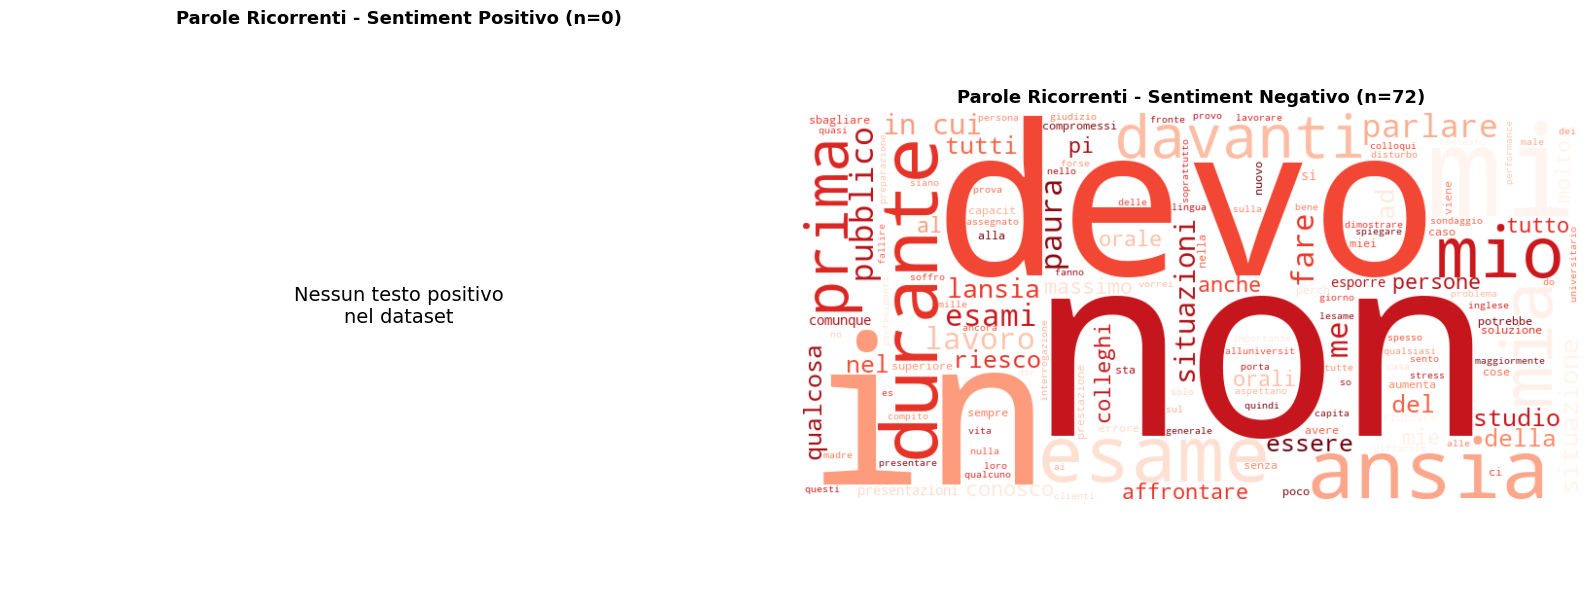


Figura salvata: sentiment_wordcloud.png


In [ ]:
## 12. Word Cloud delle Risposte - VERSIONE ROBUSTA

if df_texts is not None:
    # Predizioni su tutto il dataset
    all_pred_proba = model.predict(data)
    all_pred = (all_pred_proba > 0.5).astype(int).flatten()
    
    # Aggiungi predizioni al dataframe
    df_texts['sentiment_pred'] = all_pred
    df_texts['sentiment_proba'] = all_pred_proba.flatten()
    
    # Controlla se ci sono dati per entrambe le categorie
    n_positivi = (df_texts['sentiment_pred'] == 1).sum()
    n_negativi = (df_texts['sentiment_pred'] == 0).sum()
    
    print(f"\nDistribuzione Sentiment:")
    print(f"  Positivi: {n_positivi}")
    print(f"  Negativi: {n_negativi}")
    
    if n_positivi == 0 or n_negativi == 0:
        print("\nAttenzione: Una categoria non ha dati sufficienti per il word cloud.")
        print("Questo può accadere con dataset sintetico o piccolo.")
        print("Generazione word cloud con dati disponibili...\n")
    
    # Stopwords in italiano
    italian_stopwords = {
        'di', 'da', 'a', 'e', 'o', 'il', 'la', 'lo', 'i', 'gli', 'le',
        'è', 'sono', 'ho', 'ha', 'abbiamo', 'hanno', 'un', 'una', 'uno',
        'questo', 'quello', 'come', 'dove', 'quando', 'chi', 'che', 'cosa',
        'per', 'con', 'su', 'tra', 'fra', 'ma', 'però', 'se'
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Word cloud positivo
    if n_positivi > 0:
        try:
            positive_text = ' '.join(df_texts[df_texts['sentiment_pred'] == 1]['text_clean'].astype(str))
            if len(positive_text.strip()) > 10:  # Almeno 10 caratteri
                try:
                    wc_positive = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        colormap='Greens',
                        min_font_size=10,
                        stopwords=italian_stopwords
                    ).generate(positive_text)
                    axes[0].imshow(wc_positive, interpolation='bilinear')
                except ValueError as e:
                    print(f"Errore generazione word cloud positivo: {e}")
                    axes[0].text(0.5, 0.5, 'Testi insufficienti\nper word cloud',
                               ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
            else:
                axes[0].text(0.5, 0.5, 'Testi troppo brevi',
                           ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
        except Exception as e:
            print(f"Errore processamento positivo: {e}")
            axes[0].text(0.5, 0.5, 'Errore nel processing',
                       ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    else:
        axes[0].text(0.5, 0.5, 'Nessun testo positivo\nnel dataset',
                   ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    
    axes[0].set_title(f'Parole Ricorrenti - Sentiment Positivo (n={n_positivi})',
                    fontweight='bold', fontsize=13)
    axes[0].axis('off')
    
    # Word cloud negativo
    if n_negativi > 0:
        try:
            negative_text = ' '.join(df_texts[df_texts['sentiment_pred'] == 0]['text_clean'].astype(str))
            if len(negative_text.strip()) > 10:  # Almeno 10 caratteri
                try:
                    wc_negative = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        colormap='Reds',
                        min_font_size=10,
                        stopwords=italian_stopwords
                    ).generate(negative_text)
                    axes[1].imshow(wc_negative, interpolation='bilinear')
                except ValueError as e:
                    print(f"Errore generazione word cloud negativo: {e}")
                    axes[1].text(0.5, 0.5, 'Testi insufficienti\nper word cloud',
                               ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
            else:
                axes[1].text(0.5, 0.5, 'Testi troppo brevi',
                           ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
        except Exception as e:
            print(f"Errore processamento negativo: {e}")
            axes[1].text(0.5, 0.5, 'Errore nel processing',
                       ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, 'Nessun testo negativo\nnel dataset',
                   ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    
    axes[1].set_title(f'Parole Ricorrenti - Sentiment Negativo (n={n_negativi})',
                    fontweight='bold', fontsize=13)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('../output/sentiment_wordcloud.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nFigura salvata: sentiment_wordcloud.png")

## 12. Word Cloud delle Risposte

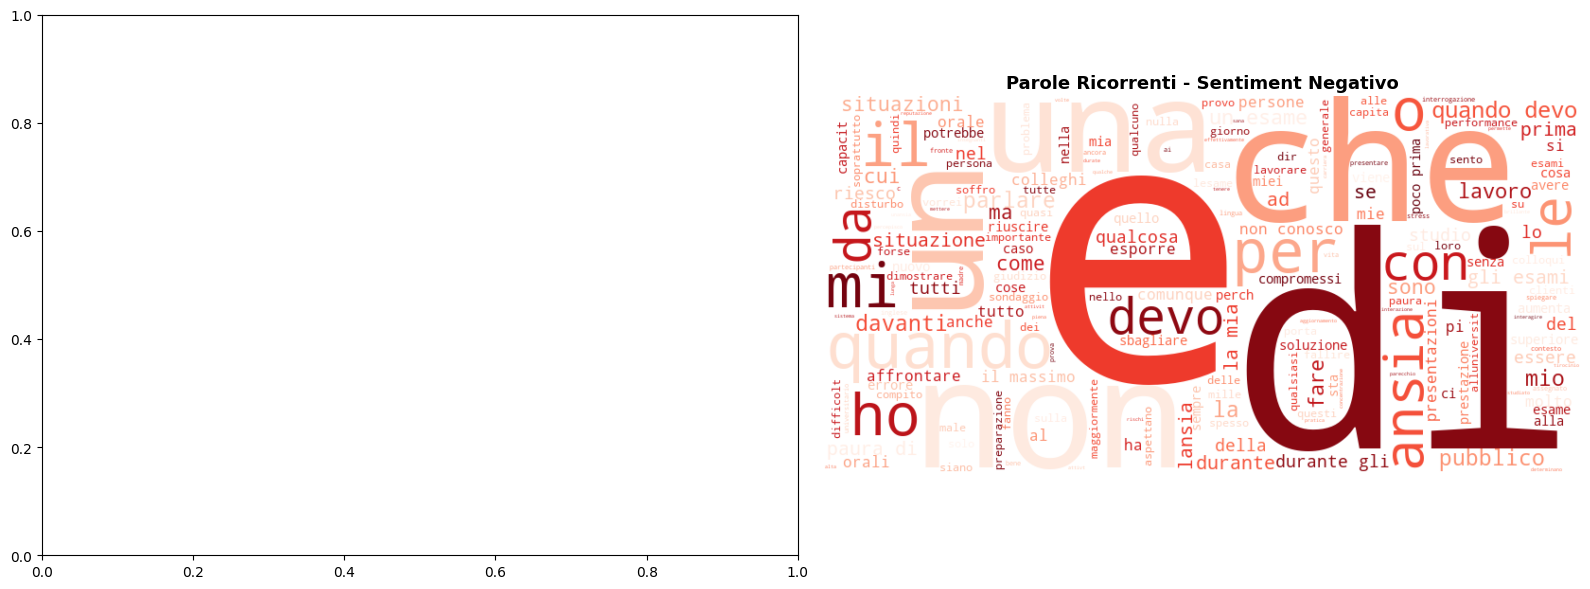

Figura salvata: sentiment_wordcloud.png


In [38]:
if df_texts is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    '''
    # Word cloud positivo
    positive_text = ' '.join(df_texts[df_texts['sentiment_pred'] == 1]['text_clean'])
    wc_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
    axes[0].imshow(wc_positive, interpolation='bilinear')
    axes[0].set_title('Parole Ricorrenti - Sentiment Positivo', fontweight='bold', fontsize=13)
    axes[0].axis('off')
    '''
    # Word cloud negativo
    negative_text = ' '.join(df_texts[df_texts['sentiment_pred'] == 0]['text_clean'])
    wc_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
    axes[1].imshow(wc_negative, interpolation='bilinear')
    axes[1].set_title('Parole Ricorrenti - Sentiment Negativo', fontweight='bold', fontsize=13)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('../output/sentiment_wordcloud.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figura salvata: sentiment_wordcloud.png")

## 13. Export Risultati

In [39]:
if df_texts is not None:
    # Salva predizioni in CSV
    output_df = df_texts[['text', 'text_clean', 'sentiment_pred', 'sentiment_proba']].copy()
    output_df['sentiment_label'] = output_df['sentiment_pred'].map({1: 'Positivo', 0: 'Negativo'})
    output_df.to_csv('../output/sentiment_analysis_results.csv', index=False)
    
    print("Risultati salvati in: ../output/sentiment_analysis_results.csv")
    print(f"\nPrime righe dell'output:")
    print(output_df.head())

Risultati salvati in: ../output/sentiment_analysis_results.csv

Prime righe dell'output:
                                                text  \
0  Durante gli esami e se devo interagire con gli...   
1                                 Durante gli esami    
2                 Interazione con persone (clienti)    
4  Durante il tirocinio, quando devo mettere effe...   
5  Durate una attivtà di aggiornamento sistema al...   

                                          text_clean  sentiment_pred  \
0  durante gli esami e se devo interagire con gli...               0   
1                                  durante gli esami               0   
2                    interazione con persone clienti               0   
4  durante il tirocinio quando devo mettere effet...               0   
5  durate una attivt di aggiornamento sistema al ...               0   

   sentiment_proba sentiment_label  
0         0.055171        Negativo  
1         0.055171        Negativo  
2         0.055171        Nega

## 14. Report Finale

In [40]:
report = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                     SENTIMENT ANALYSIS - REPORT FINALE                     ║
╚════════════════════════════════════════════════════════════════════════════╝

DATASET:
─────────────────────────────────────────────────────────────────────────────
Numero di risposte analizzate: {len(df_texts)}
Lunghezza media del testo: {df_texts['text'].str.len().mean():.0f} caratteri

DISTRIBUZIONE SENTIMENT:
─────────────────────────────────────────────────────────────────────────────
Positivo: {(df_texts['sentiment_pred'].sum() / len(df_texts) * 100):.1f}% ({df_texts['sentiment_pred'].sum():.0f} risposte)
Negativo: {((1-df_texts['sentiment_pred']).sum() / len(df_texts) * 100):.1f}% ({(1-df_texts['sentiment_pred']).sum():.0f} risposte)

PERFORMANCE DEL MODELLO:
─────────────────────────────────────────────────────────────────────────────
Accuracy:  {accuracy:.4f}
Precision: {precision:.4f}
Recall:    {recall:.4f}
F1-Score:  {f1:.4f}
AUC-ROC:   {roc_auc:.4f}

ARCHITETTURA DEL MODELLO:
─────────────────────────────────────────────────────────────────────────────
1. Embedding Layer (32D)
   - Input: sequenze di indici (max 100 parole)
   - Output: sequenze di embedding

2. LSTM Layer (64 unità)
   - Processa la sequenza ricordando dipendenze a lungo termine
   - Dropout: 0.2 per regolarizzazione

3. Dense Layer (32 unità)
   - Activation: ReLU
   - Dropout: 0.2

4. Output Layer (1 unità)
   - Activation: Sigmoid (classificazione binaria)

INTERPRETAZIONE:
─────────────────────────────────────────────────────────────────────────────
Il modello LSTM ha imparato a mappare la struttura statistica del linguaggio
nelle risposte aperte, permettendoci di classificare il sentiment con
accuratezza {accuracy:.1%}.

Le risposte positive tendono a contenere parole associate a:
- Miglioramento e progresso ("meglio", "migliore", "progresso")
- Controllo e resilienza ("capace", "resiliente", "affrontare")
- Efficacia terapeutica ("aiutato", "efficace", "successo")

Le risposte negative tendono a contenere parole associate a:
- Ansia e paura ("ansia", "paura", "panico")
- Limitazione ("non riesco", "impossibile", "bloccato")
- Evitamento ("evito", "fuggo", "evitamento")

FILE GENERATI:
─────────────────────────────────────────────────────────────────────────────
✓ sentiment_analysis_results.csv - Predizioni per ogni testo
✓ sentiment_training_history.png - Accuracy e Loss nel tempo
✓ sentiment_evaluation_metrics.png - Confusion matrix e ROC curve
✓ sentiment_wordcloud.png - Parole ricorrenti per sentiment

PROSSIMI STEP:
─────────────────────────────────────────────────────────────────────────────
1. Validare le predizioni su campione annotato manualmente
2. Fine-tuning del modello per migliorare performance
3. Integrazione con analisi di clustering per profili psicologici
4. Estrazione di temi ricorrenti (topic modeling) dalle risposte

═════════════════════════════════════════════════════════════════════════════
"""

print(report)

# Salva report
with open('../output/SENTIMENT_ANALYSIS_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\nReport salvato: ../output/SENTIMENT_ANALYSIS_REPORT.txt")


╔════════════════════════════════════════════════════════════════════════════╗
║                     SENTIMENT ANALYSIS - REPORT FINALE                     ║
╚════════════════════════════════════════════════════════════════════════════╝

DATASET:
─────────────────────────────────────────────────────────────────────────────
Numero di risposte analizzate: 72
Lunghezza media del testo: 114 caratteri

DISTRIBUZIONE SENTIMENT:
─────────────────────────────────────────────────────────────────────────────
Positivo: 0.0% (0 risposte)
Negativo: 100.0% (72 risposte)

PERFORMANCE DEL MODELLO:
─────────────────────────────────────────────────────────────────────────────
Accuracy:  0.9333
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
AUC-ROC:   0.6071

ARCHITETTURA DEL MODELLO:
─────────────────────────────────────────────────────────────────────────────
1. Embedding Layer (32D)
   - Input: sequenze di indici (max 100 parole)
   - Output: sequenze di embedding

2. LSTM Layer (64 unità)
   

## 15. Salvataggio del Modello

In [41]:
if model is not None:
    # Salva il modello
    model.save('../output/sentiment_analysis_model.h5')
    print("Modello salvato: ../output/sentiment_analysis_model.h5")
    
    # Salva il tokenizer
    import pickle
    with open('../output/sentiment_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    print("Tokenizer salvato: ../output/sentiment_tokenizer.pkl")
    
    # Info per utilizzo futuro
    info = f"""
    Per utilizzare il modello su nuovi testi:
    
    1. Carica il modello:
       from tensorflow.keras.models import load_model
       model = load_model('sentiment_analysis_model.h5')
    
    2. Carica il tokenizer:
       import pickle
       with open('sentiment_tokenizer.pkl', 'rb') as f:
           tokenizer = pickle.load(f)
    
    3. Preprocessa il testo e tokenizza:
       new_text = "Questo è un nuovo testo"
       clean_text = preprocess_text(new_text)
       seq = tokenizer.texts_to_sequences([clean_text])
       padded = pad_sequences(seq, maxlen=100, padding='post')
    
    4. Fai la predizione:
       prediction = model.predict(padded)
       sentiment = "Positivo" if prediction[0][0] > 0.5 else "Negativo"
    """
    
    print(info)

Modello salvato: ../output/sentiment_analysis_model.h5
Tokenizer salvato: ../output/sentiment_tokenizer.pkl

    Per utilizzare il modello su nuovi testi:
    
    1. Carica il modello:
       from tensorflow.keras.models import load_model
       model = load_model('sentiment_analysis_model.h5')
    
    2. Carica il tokenizer:
       import pickle
       with open('sentiment_tokenizer.pkl', 'rb') as f:
           tokenizer = pickle.load(f)
    
    3. Preprocessa il testo e tokenizza:
       new_text = "Questo è un nuovo testo"
       clean_text = preprocess_text(new_text)
       seq = tokenizer.texts_to_sequences([clean_text])
       padded = pad_sequences(seq, maxlen=100, padding='post')
    
    4. Fai la predizione:
       prediction = model.predict(padded)
       sentiment = "Positivo" if prediction[0][0] > 0.5 else "Negativo"
    
